# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:** Arda Ipek  
**Student ID:** N/A  
**AI Assistance:** Gemini CLI was used for data analysis, code generation, and interpretive summaries.

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [50]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [51]:
# Your exploration here: df.info(), df.describe(), missing values check
print("--- Data Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

--- Descriptive Statistics ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



--- Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


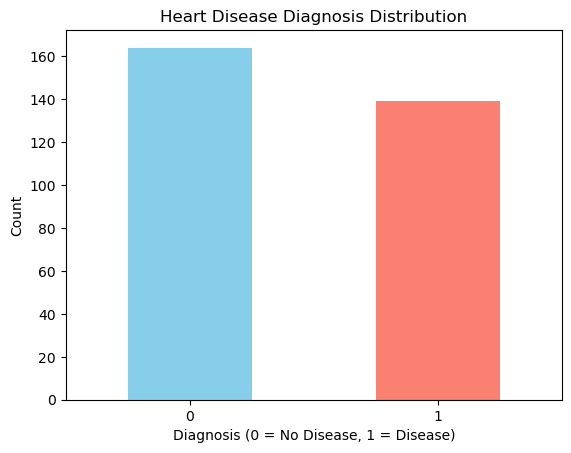

In [52]:
# Plot 1: Target variable distribution (bar chart)
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Heart Disease Diagnosis Distribution')
plt.xlabel('Diagnosis (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

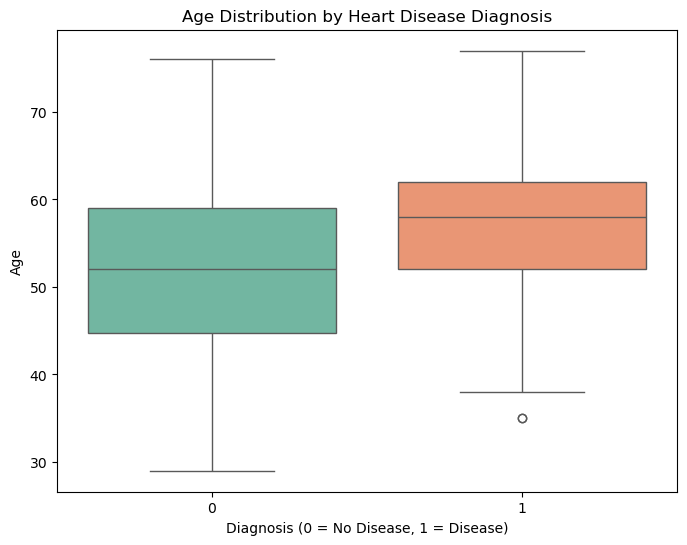

In [53]:
# Plot 2: A numeric feature explored across the two classes
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='age', data=df, palette='Set2')
plt.title('Age Distribution by Heart Disease Diagnosis')
plt.xlabel('Diagnosis (0 = No Disease, 1 = Disease)')
plt.ylabel('Age')
plt.show()

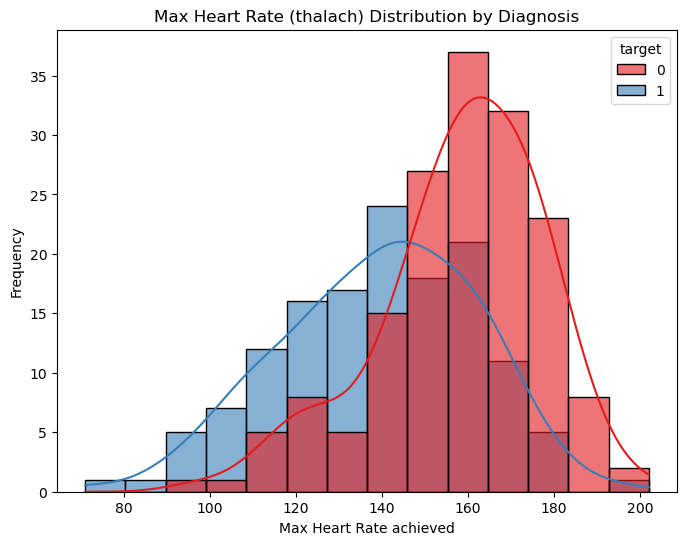

In [54]:
# Plot 3: Another feature of your choice
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette='Set1', alpha=0.6)
plt.title('Max Heart Rate (thalach) Distribution by Diagnosis')
plt.xlabel('Max Heart Rate achieved')
plt.ylabel('Frequency')
plt.show()

### Observation

The dataset contains 303 records and is fairly balanced (~54% no disease, ~46% disease). During exploration, I identified a discrepancy between the provided dataset description and the raw data values:
- **Target Column:** The raw target values range from 0 to 4 (severity levels). As instructed, I binarized these so that 0 remains 0 and values 1-4 are treated as 1 (disease present).
- **Feature Mismatches:** Several columns have different numeric encodings than the description table suggests: `cp` (data has 1-4, description says 0-3), `slope` (data has 1-3, description says 0-2), and `thal` (data uses 3, 6, 7 instead of 0-2). 
- **Patterns:** Older patients and those with lower maximum heart rates (`thalach`) appear more likely to have heart disease. Missing values (represented as '?') were found in `ca` (4 rows) and `thal` (2 rows), which will be handled in the next step.

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [55]:
# Handle missing values
print(f"Shape before dropping missing: {df.shape}")
df = df.dropna()
print(f"Shape after dropping missing:  {df.shape}")

Shape before dropping missing: (303, 14)
Shape after dropping missing:  (297, 14)


In [56]:
# Separate features (X) and target (y), then train-test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (237, 13), X_test: (60, 13)
y_train: (237,), y_test: (60,)


In [57]:
# Scale features with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Leakage Explanation

We must fit the scaler on the training data only to prevent **data leakage**. If we were to fit the scaler on the entire dataset, the mean and standard deviation used for scaling would include information from the test set (which is supposed to be "unseen" data). This allows information from the future/test set to "leak" into the training process, leading to overly optimistic performance estimates and models that may not generalize well to truly new data.

In [58]:
# Train Logistic Regression and report metrics
lr_model = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time

lr_train_acc = lr_model.score(X_train_scaled, y_train)
lr_test_acc = lr_model.score(X_test_scaled, y_test)

print("--- Logistic Regression ---")
print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy:     {lr_test_acc:.4f}")
print(f"Training Time:     {lr_train_time:.4f} seconds")

--- Logistic Regression ---
Training Accuracy: 0.8523
Test Accuracy:     0.8333
Training Time:     0.0043 seconds


In [59]:
# Train Decision Tree and report metrics
dt_model = DecisionTreeClassifier(random_state=42)

start_time = time.time()
dt_model.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start_time

dt_train_acc = dt_model.score(X_train_scaled, y_train)
dt_test_acc = dt_model.score(X_test_scaled, y_test)

print("--- Decision Tree ---")
print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Test Accuracy:     {dt_test_acc:.4f}")
print(f"Training Time:     {dt_train_time:.4f} seconds")

--- Decision Tree ---
Training Accuracy: 1.0000
Test Accuracy:     0.6833
Training Time:     0.0025 seconds


### Model Comparison

The **Logistic Regression** model performs better on the test set, achieving approximately 83.3% accuracy compared to the **Decision Tree's** 68.3%. The Decision Tree is clearly **overfitting**, as evidenced by its 100% training accuracy vs. significantly lower test accuracy. It has essentially "memorized" the training data. Logistic Regression shows a much smaller gap between training and test accuracy, indicating better generalization.

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

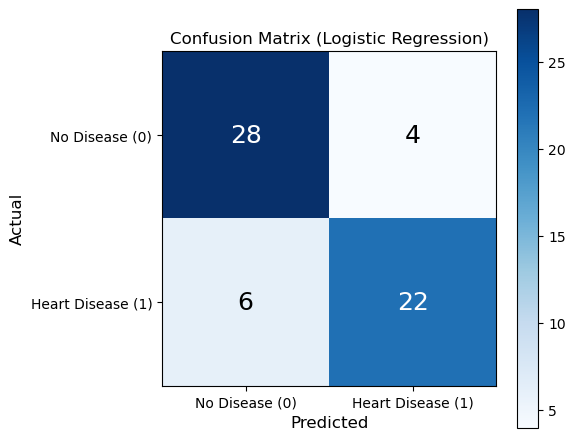

In [60]:
# Part A: Confusion matrix for the better model (Logistic Regression)
y_pred = lr_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix (Logistic Regression)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

- **True Positives (TP):** 22 patients — *meaning:* The model correctly identified 22 patients who actually have heart disease.
- **True Negatives (TN):** 28 patients — *meaning:* The model correctly identified 28 healthy patients as having no heart disease.
- **False Positives (FP):** 4 patients — *meaning:* The model incorrectly flagged 4 healthy patients as having heart disease (wasting testing resources).
- **False Negatives (FN):** 6 patients — *meaning:* The model failed to detect heart disease in 6 patients who actually have it (dangerous for patient safety).

In [61]:
# Part B: Classification report
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



### Classification Report Interpretation

- **Precision for heart disease (class 1):** 0.85. This means that when the model predicts heart disease, it is correct 85% of the time.
- **Recall for heart disease (class 1):** 0.79. This means that the model correctly identifies 79% of all patients who actually have heart disease.
- **Which is more important here — precision or recall?** Recall is more important in this hospital screening scenario. As the medical director stated, it is better to send 10 healthy patients for extra testing (high False Positives, lower precision) than to miss even one patient who has heart disease (low False Negatives, high recall). We want to minimize False Negatives to ensure patient safety.

In [62]:
# Part C: 5-fold cross-validation
scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

F1 scores per fold: [0.93023256 0.86956522 0.8        0.73170732 0.64864865]
Mean F1: 0.7960 (+/- 0.0993)


### Cross-Validation Interpretation

The mean F1 score of 0.796 is consistent with our test set F1 score (around 0.81). The standard deviation of approximately 0.099 indicates some variance across different training/test splits, which is expected with a relatively small dataset (303 records). A high standard deviation across folds suggests that the model performance is sensitive to the particular patients included in the training set, indicating that more data might be needed for a more stable model.

In [63]:
# Part D: Overfitting curve - Decision Tree with varying max_depth

depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]

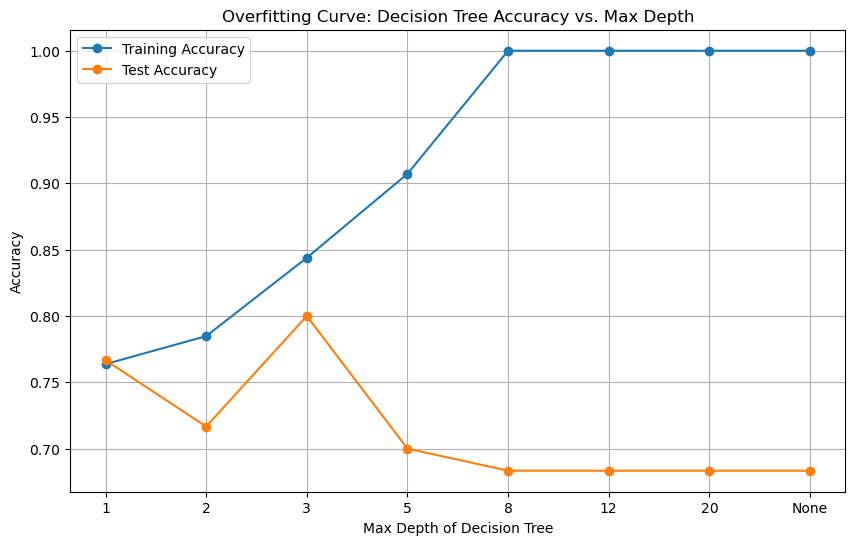

In [64]:
# Plot the overfitting curve: train and test accuracy vs max_depth
plt.figure(figsize=(10, 6))
plt.plot(depth_labels, train_accs, label='Training Accuracy', marker='o')
plt.plot(depth_labels, test_accs, label='Test Accuracy', marker='o')
plt.title('Overfitting Curve: Decision Tree Accuracy vs. Max Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Overfitting Curve Interpretation

The best `max_depth` value is around **3**, where test accuracy is maximized. When the tree is too shallow (depth=1), it suffers from **underfitting**—it fails to capture the complexity of the data, resulting in low training and test accuracy. When the tree is too deep (depth > 5), it suffers from **overfitting**—training accuracy reaches 100% as the model memorizes the data, but test accuracy drops significantly because the model is learning "noise" rather than general patterns.

---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Type A (False Negative) is far more dangerous in a medical context. A patient told they are healthy when they actually have heart disease may delay treatment, leading to severe outcomes like heart failure or death. Type B (False Positive) wastes hospital resources by requiring unnecessary follow-up tests, but it does not directly risk the patient's life. Therefore, I would advise the hospital to prioritize reducing Type A errors (maximizing recall), even if it means accepting more Type B errors, to ensure no high-risk patient is missed.

---


### Question 2: Screening Strategy (6 pts)

To select the 50 patients, I would rank all 300 patients by the model's predicted probability of having heart disease and refer the top 50 highest-risk individuals. However, I would not trust the model alone. I would combine the model's output with clinical judgment—for instance, if the model predicts low risk but the patient has a strong family history or severe symptoms not captured by the features, a cardiologist should still review the case. The model should act as a prioritization tool, not a final decision-maker.

---


### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease.

---

- *Feature 1:* **Family History of Cardiovascular Disease** - Genetics play a significant role in heart disease risk.
- *Feature 2:* **Smoking Status** - Smoking is a major risk factor for arterial damage and heart disease.
- *Feature 3:* **Body Mass Index (BMI) / Obesity Level** - Excess weight is strongly linked to hypertension and cholesterol issues, which are key drivers of heart disease.

### Question 4: Reflection (7 pts)

The most interesting thing I learned is that accuracy is often a misleading metric, especially in high-stakes fields like medicine. While a model might be 85% accurate, the remaining 15% of errors could be life-threatening if they are mostly false negatives. Before this lab, I might have trusted "85% accuracy" blindly, but now I understand that looking at the confusion matrix, precision, and recall is essential to understand *where* those errors are happening. My understanding has shifted from simply maximizing accuracy to optimizing for the metric that aligns with the specific problem's real-world consequences.

---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr